*COMP1816 - Machine Learning Coursework*

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
#Load dataset
df = pd.read_csv('/content/Food Delivery Dataset.csv')

#EDA
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Dataset Info ---")
print(df.info())


--- First 5 Rows ---
  market_id store_primary_category order_protocol  total_items  subtotal  \
0    AREA B               japanese     Protocol 1            4       875   
1    AREA A                dessert     Protocol 1            5      5345   
2    AREA A                 burger     Protocol 5            4      2150   
3    AREA A                   thai     Protocol 5            5      3570   
4    AREA D                dessert     Protocol 1            3      2485   

   min_item_price  max_item_price  total_onshift_partners  \
0             175             350                    82.0   
1             295            1995                    50.0   
2              50            1300                    32.0   
3             175            1195                    61.0   
4             295            1195                    75.0   

   total_busy_partners  total_outstanding_orders created_day created_holiday  \
0                 79.0                     104.0    Saturday              

In [ ]:
print("\n========== FEATURE ENGINEERING ==========")

df['created_at'] = pd.to_datetime(df['created_at'], format='%H:%M:%S')
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], format='%H:%M:%S')

df['delivery_time'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60

# Fix negative times (overnight delivery)
df.loc[df['delivery_time'] < 0, 'delivery_time'] += 24 * 60

print("\n--- Delivery Time Sample ---")
print(df[['created_at', 'actual_delivery_time', 'delivery_time']].head())


========== FEATURE ENGINEERING ==========

--- Delivery Time Sample ---
           created_at actual_delivery_time  delivery_time
0 1900-01-01 05:04:03  1900-01-01 05:38:01      33.966667
1 1900-01-01 02:27:48  1900-01-01 03:15:36      47.800000
2 1900-01-01 04:15:41  1900-01-01 05:29:14      73.550000
3 1900-01-01 03:43:41  1900-01-01 04:14:56      31.250000
4 1900-01-01 04:14:36  1900-01-01 05:14:07      59.516667


In [ ]:
print("\n========== NUMERICAL ANALYSIS ==========")

num_cols = [
    'total_items', 'subtotal', 'min_item_price', 'max_item_price',
    'total_onshift_partners', 'total_busy_partners',
    'total_outstanding_orders', 'delivery_time'
]

print("\n--- Summary Statistics ---")
print(df[num_cols].describe())

print("\n--- Median Values ---")
print(df[num_cols].median())

print("\n--- Standard Deviation ---")
print(df[num_cols].std())


========== NUMERICAL ANALYSIS ==========

--- Summary Statistics ---
       total_items     subtotal  min_item_price  max_item_price  \
count  1000.000000   1000.00000     1000.000000     1000.000000   
mean      3.147000   2674.94200      688.048000     1141.950000   
std       2.385599   1859.07752      496.879802      513.886087   
min       1.000000    275.00000        0.000000      169.000000   
25%       2.000000   1445.00000      299.000000      799.000000   
50%       3.000000   2134.00000      600.000000     1095.000000   
75%       4.000000   3429.00000      976.000000     1400.000000   
max      24.000000  13019.00000     4400.000000     4400.000000   

       total_onshift_partners  total_busy_partners  total_outstanding_orders  \
count              920.000000           920.000000                920.000000   
mean                45.660870            43.020652                 60.033696   
std                 33.481422            32.330324                 53.531173   
min   


========== DISTRIBUTION ANALYSIS ==========

--- Distribution of total_items ---


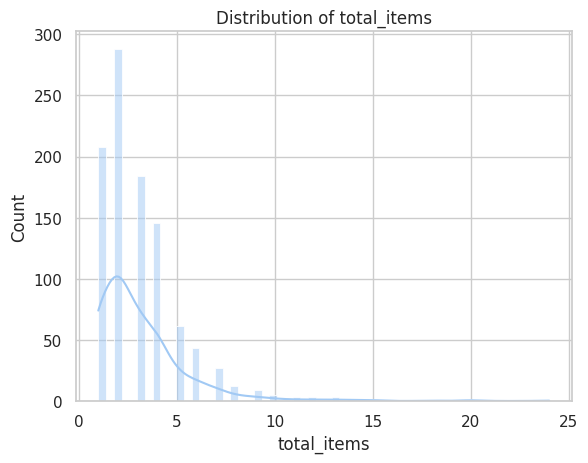


--- Distribution of subtotal ---


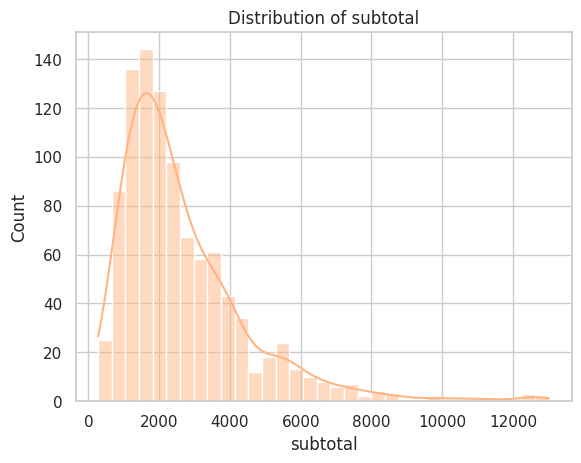


--- Distribution of min_item_price ---


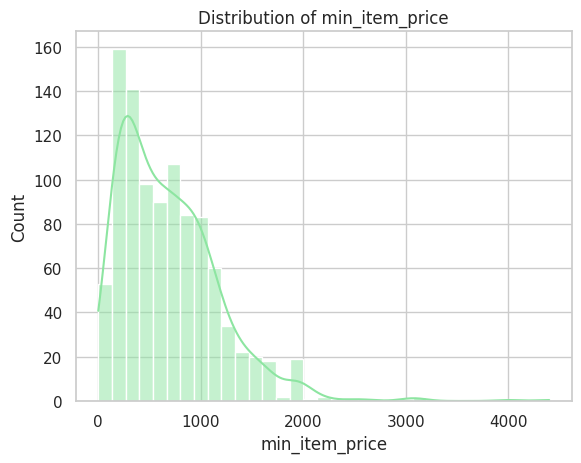


--- Distribution of max_item_price ---


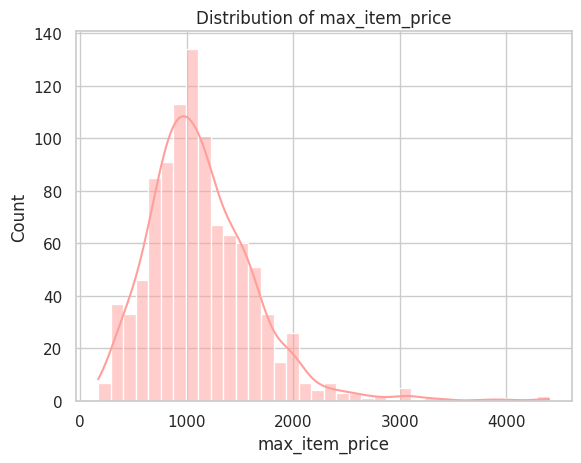


--- Distribution of total_onshift_partners ---


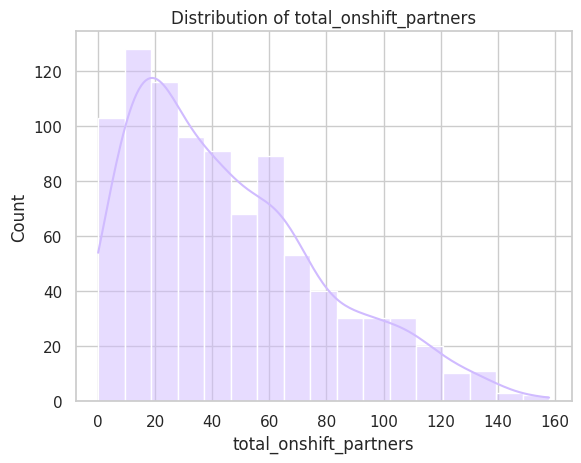


--- Distribution of total_busy_partners ---


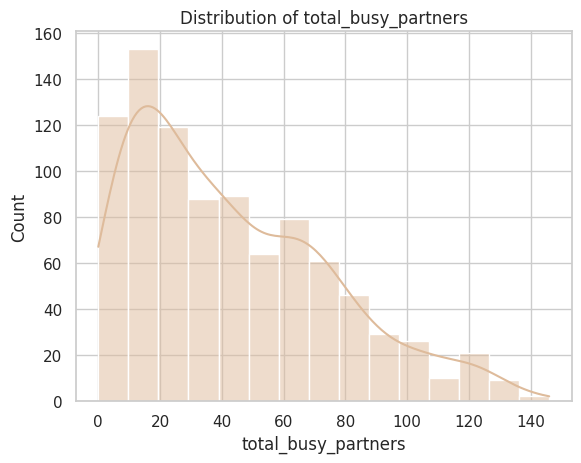


--- Distribution of total_outstanding_orders ---


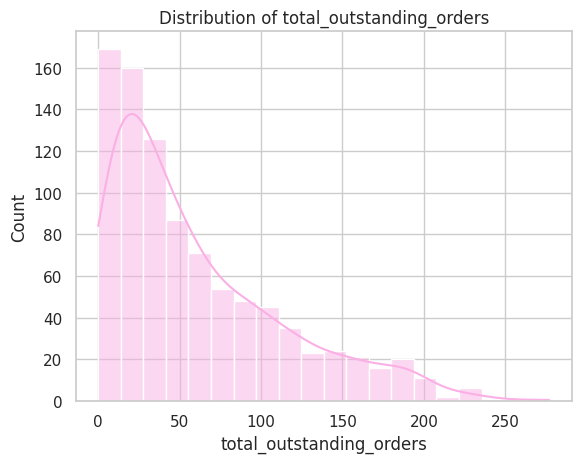


--- Distribution of delivery_time ---


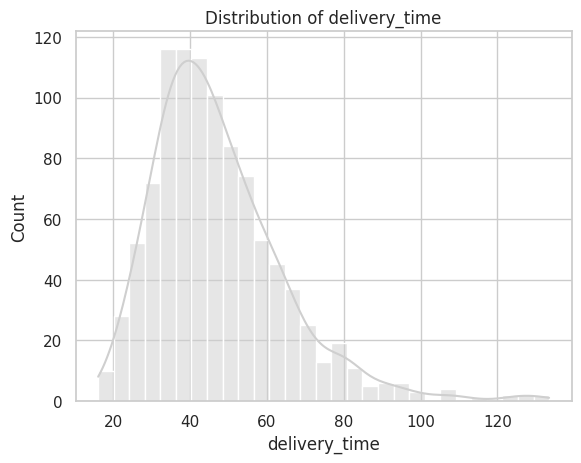

In [ ]:
#Distribution Analysis
print("\n========== DISTRIBUTION ANALYSIS ==========")

pastel_colors = sns.color_palette("pastel", len(num_cols))

for i, col in enumerate(num_cols):
    print(f"\n--- Distribution of {col} ---")
    plt.figure()
    sns.histplot(df[col], kde=True, color=pastel_colors[i])
    plt.title(f'Distribution of {col}')
    plt.show()


========== CATEGORICAL ANALYSIS ==========

--- Orders by Day ---


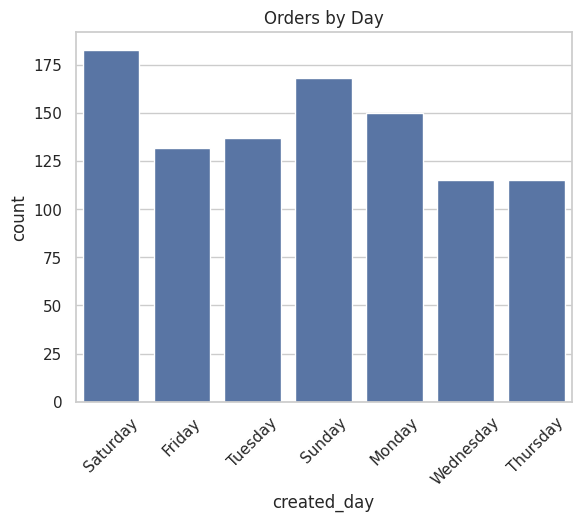


--- Holiday vs Non-Holiday ---


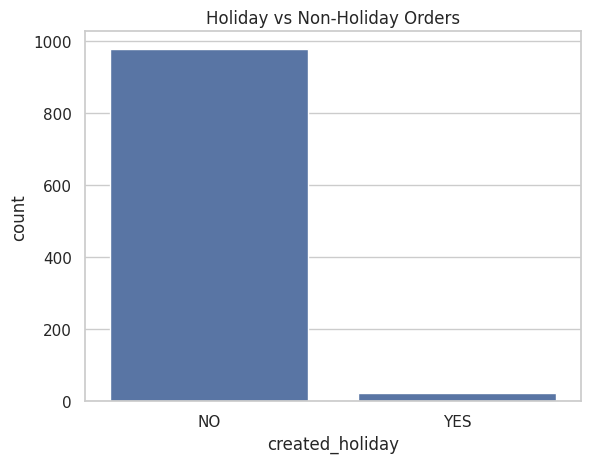

In [ ]:
#Categorical Analysis
print("\n========== CATEGORICAL ANALYSIS ==========")

print("\n--- Orders by Day ---")
plt.figure()
sns.countplot(x='created_day', data=df)
plt.xticks(rotation=45)
plt.title('Orders by Day')
plt.show()

print("\n--- Holiday vs Non-Holiday ---")
plt.figure()
sns.countplot(x='created_holiday', data=df)
plt.title('Holiday vs Non-Holiday Orders')
plt.show()


========== CORRELATION ANALYSIS ==========


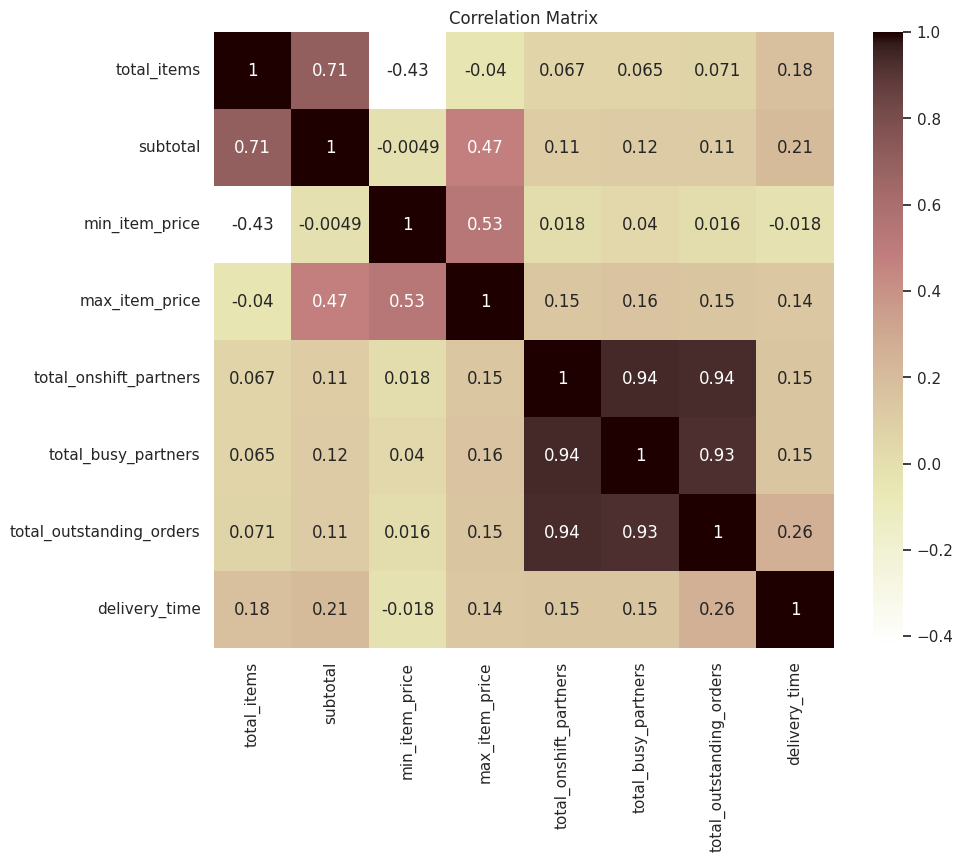

In [ ]:
#Correlation Analysis

print("\n========== CORRELATION ANALYSIS ==========")

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='pink_r')
plt.title('Correlation Matrix')
plt.show()


========== DELIVERY TIME RELATIONSHIPS ==========


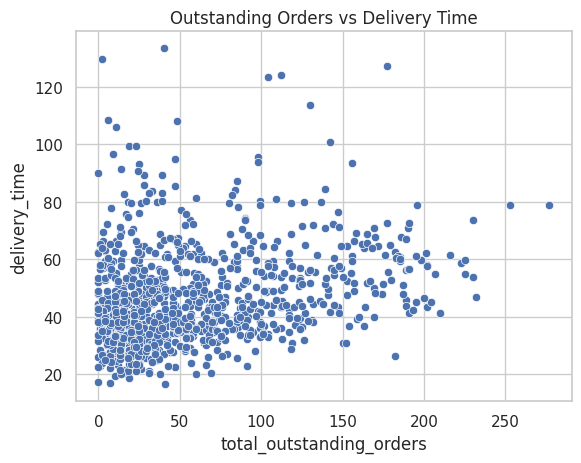

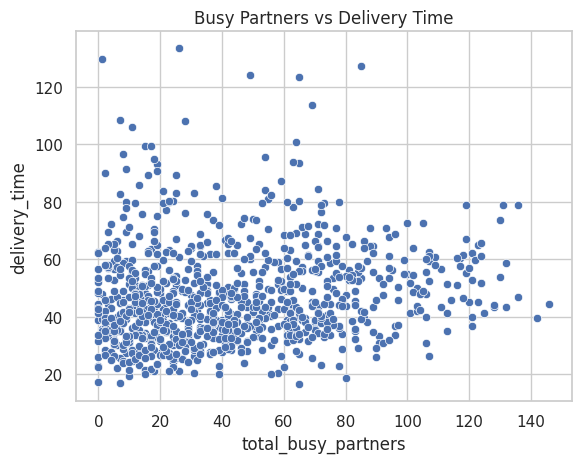

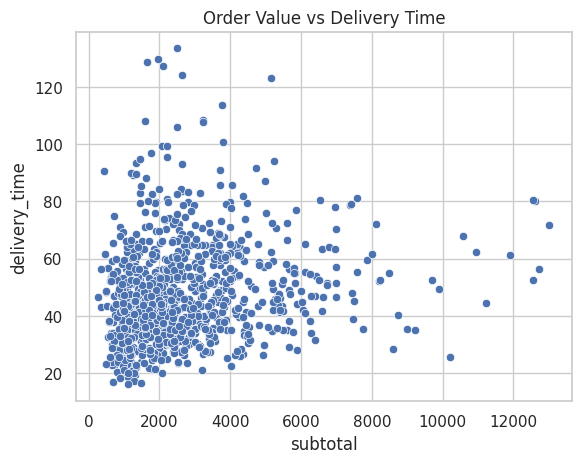

In [ ]:
#Relationship Analysis

print("\n========== DELIVERY TIME RELATIONSHIPS ==========")

plt.figure()
sns.scatterplot(x='total_outstanding_orders', y='delivery_time', data=df)
plt.title('Outstanding Orders vs Delivery Time')
plt.show()

plt.figure()
sns.scatterplot(x='total_busy_partners', y='delivery_time', data=df)
plt.title('Busy Partners vs Delivery Time')
plt.show()

plt.figure()
sns.scatterplot(x='subtotal', y='delivery_time', data=df)
plt.title('Order Value vs Delivery Time')
plt.show()


========== COMPLAINT ANALYSIS ==========


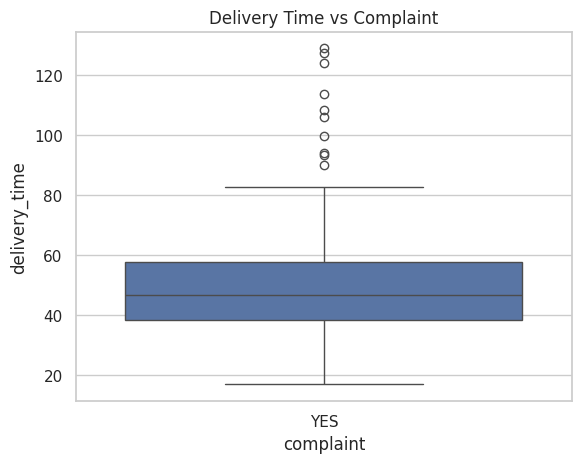

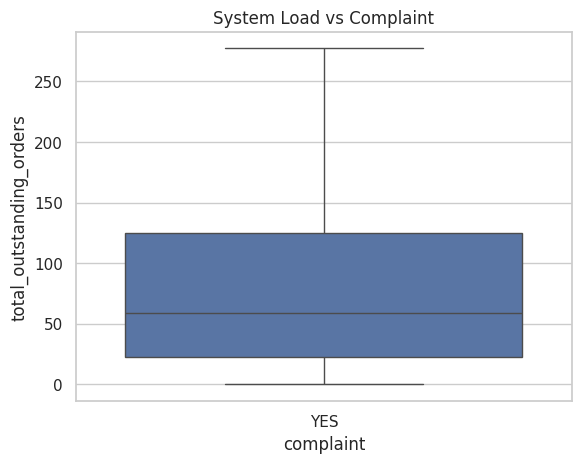

In [ ]:
print("\n========== COMPLAINT ANALYSIS ==========")

plt.figure()
sns.boxplot(x='complaint', y='delivery_time', data=df)
plt.title('Delivery Time vs Complaint')
plt.show()

plt.figure()
sns.boxplot(x='complaint', y='total_outstanding_orders', data=df)
plt.title('System Load vs Complaint')
plt.show()

========== CLUSTERING ==========

========== 1. FEATURE SELECTION ==========

--- Features Used for Clustering ---
['total_items', 'subtotal', 'total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders']

--- Raw Data Shape ---
(1000, 5)

--- Missing Values Before Imputation ---
total_items                  0
subtotal                     0
total_onshift_partners      80
total_busy_partners         80
total_outstanding_orders    80
dtype: int64

========== 2. PREPROCESSING ==========

Preprocessing complete: median imputation + standardisation.

========== 3. MODEL SELECTION: CHOOSING k ==========

--- Elbow + Silhouette Results ---
   k      inertia  silhouette_score
0  2  2956.553514          0.437959
1  3  2087.914325          0.460067
2  4  1692.452344          0.317027
3  5  1465.200040          0.318729
4  6  1279.540035          0.289738


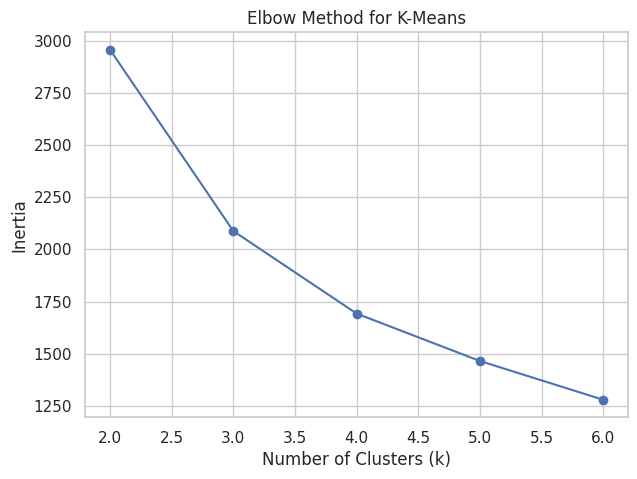

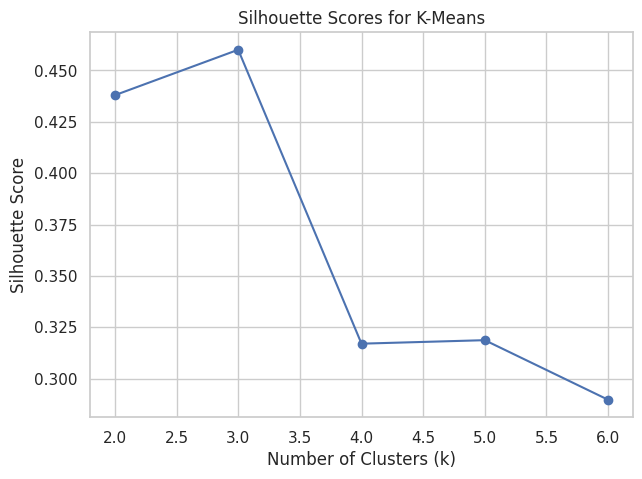


========== 4. K-MEANS MODEL (k=3) ==========

--- Cluster Counts ---
cluster
0    267
1     97
2    636
Name: count, dtype: int64

========== 5. CLUSTER SUMMARY ==========
         total_items  subtotal  total_onshift_partners  total_busy_partners  \
cluster                                                                       
0               2.88   2611.66                   87.24                83.09   
1               7.97   6656.82                   45.16                42.87   
2               2.53   2094.21                   25.95                23.98   

         total_outstanding_orders  
cluster                            
0                          126.98  
1                           56.64  
2                           28.73  

========== 6. REPRESENTATIVE ORDER EXAMPLES ==========

--- Representative Example for Each Cluster ---
  market_id store_primary_category order_protocol  total_items  subtotal  \
0    AREA D             vietnamese     Protocol 1            3      21

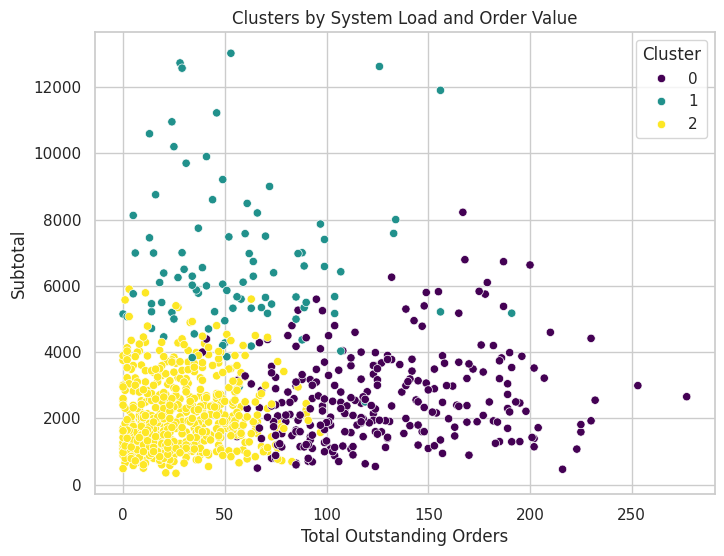

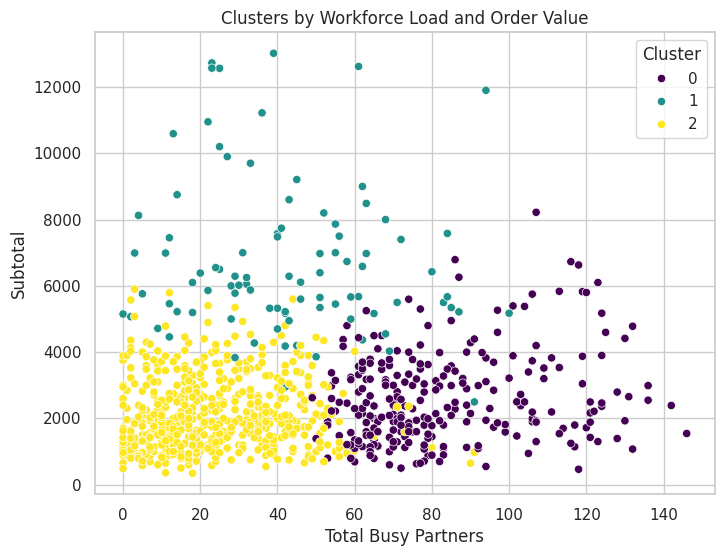

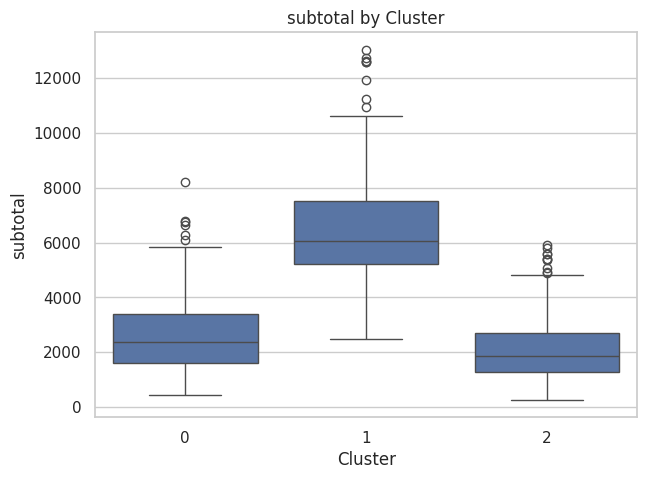

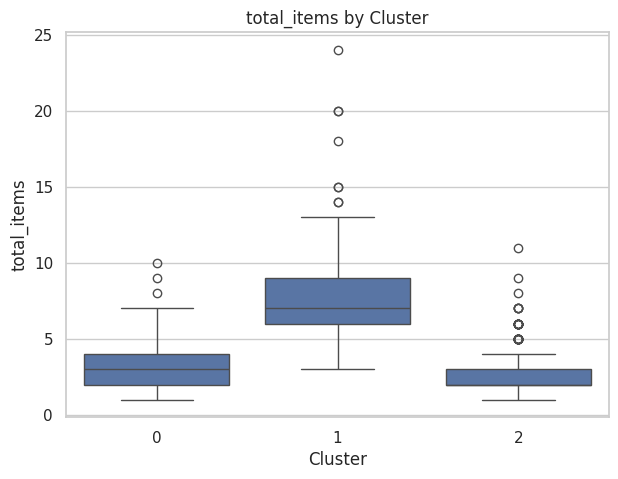

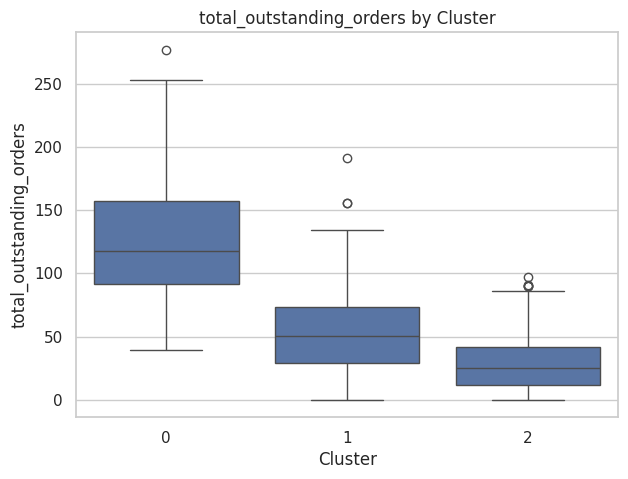

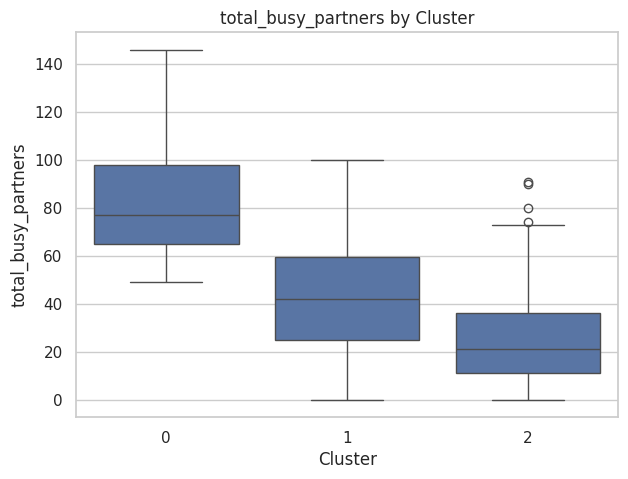

In [ ]:
print("========== CLUSTERING ==========")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --------------------------------------------------
# 1. SELECT FEATURES
# --------------------------------------------------
print("\n========== 1. FEATURE SELECTION ==========")

cluster_features = [
    'total_items',
    'subtotal',
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders'
]

print("\n--- Features Used for Clustering ---")
print(cluster_features)

df_cluster = df[cluster_features].copy()

print("\n--- Raw Data Shape ---")
print(df_cluster.shape)

print("\n--- Missing Values Before Imputation ---")
print(df_cluster.isnull().sum())


# --------------------------------------------------
# 2. IMPUTATION + SCALING
# --------------------------------------------------
print("\n========== 2. PREPROCESSING ==========")

# Median imputation for skewed numeric variables
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_cluster)

# Standardisation for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("\nPreprocessing complete: median imputation + standardisation.")


# --------------------------------------------------
# 3. CHOOSE K USING ELBOW + SILHOUETTE
# --------------------------------------------------
print("\n========== 3. MODEL SELECTION: CHOOSING k ==========")

k_values = range(2, 7)
inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

selection_df = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_values,
    'silhouette_score': silhouette_values
})

print("\n--- Elbow + Silhouette Results ---")
print(selection_df)

# Plot inertia
plt.figure(figsize=(7, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.show()

# Plot silhouette
plt.figure(figsize=(7, 5))
plt.plot(k_values, silhouette_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means')
plt.show()


# --------------------------------------------------
# 4. FINAL MODEL WITH k = 3
# --------------------------------------------------
print("\n========== 4. K-MEANS MODEL (k=3) ==========")

final_k = 3
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print("\n--- Cluster Counts ---")
print(df_clustered['cluster'].value_counts().sort_index())


# --------------------------------------------------
# 5. CLUSTER SUMMARY
# --------------------------------------------------
print("\n========== 5. CLUSTER SUMMARY ==========")

cluster_summary = df_clustered.groupby('cluster')[cluster_features].mean().round(2)
print(cluster_summary)


# --------------------------------------------------
# 6. REPRESENTATIVE ORDER EXAMPLES
# --------------------------------------------------
print("\n========== 6. REPRESENTATIVE ORDER EXAMPLES ==========")

# Find representative examples closest to cluster centroids
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features, index=df_clustered.index)

representative_examples = []

for cluster_id in range(final_k):
    cluster_indices = df_clustered[df_clustered['cluster'] == cluster_id].index

    # centroid in scaled space
    centroid = kmeans_final.cluster_centers_[cluster_id]

    # distance of each point in cluster to centroid
    cluster_points = X_scaled_df.loc[cluster_indices].values
    distances = np.linalg.norm(cluster_points - centroid, axis=1)

    # closest point
    closest_idx = cluster_indices[np.argmin(distances)]

    representative_examples.append(df_clustered.loc[closest_idx, [
        'market_id',
        'store_primary_category',
        'order_protocol',
        'total_items',
        'subtotal',
        'total_onshift_partners',
        'total_busy_partners',
        'total_outstanding_orders',
        'created_day',
        'created_holiday',
        'cluster'
    ]])

representative_df = pd.DataFrame(representative_examples).reset_index(drop=True)

print("\n--- Representative Example for Each Cluster ---")
print(representative_df)


# --------------------------------------------------
# 7. VISUALISATIONS
# --------------------------------------------------
print("\n========== 7. CLUSTER VISUALISATIONS ==========")

# Scatter plot 1: outstanding orders vs subtotal
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clustered,
    x='total_outstanding_orders',
    y='subtotal',
    hue='cluster',
    palette='viridis'
)
plt.title('Clusters by System Load and Order Value')
plt.xlabel('Total Outstanding Orders')
plt.ylabel('Subtotal')
plt.legend(title='Cluster')
plt.show()

# Scatter plot 2: busy partners vs subtotal
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clustered,
    x='total_busy_partners',
    y='subtotal',
    hue='cluster',
    palette='viridis'
)
plt.title('Clusters by Workforce Load and Order Value')
plt.xlabel('Total Busy Partners')
plt.ylabel('Subtotal')
plt.legend(title='Cluster')
plt.show()

# Boxplots for interpretation
plot_features = ['subtotal', 'total_items', 'total_outstanding_orders', 'total_busy_partners']

for feature in plot_features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df_clustered, x='cluster', y=feature)
    plt.title(f'{feature} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.show()

In [ ]:
print("========== TASK B: DELIVERY TIME PREDICTION ==========")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

========== TASK B: DELIVERY TIME PREDICTION ==========


In [ ]:
print("\n========== 1. TARGET CONSTRUCTION AND FEATURE ENGINEERING ==========")

df_reg = df.copy()

# Change this if your column is named differently
actual_delivery_col = 'actual_delivery_time'

# Convert time columns
df_reg['created_at_dt'] = pd.to_datetime(df_reg['created_at'], format='%H:%M:%S')
df_reg['actual_delivery_time_dt'] = pd.to_datetime(df_reg[actual_delivery_col], format='%H:%M:%S')

# Create delivery time in minutes
df_reg['delivery_time'] = (
    df_reg['actual_delivery_time_dt'] - df_reg['created_at_dt']
).dt.total_seconds() / 60

# Correct overnight deliveries
df_reg.loc[df_reg['delivery_time'] < 0, 'delivery_time'] += 24 * 60

# Basic order-time features
df_reg['created_hour'] = df_reg['created_at_dt'].dt.hour
df_reg['created_minute'] = df_reg['created_at_dt'].dt.minute
df_reg['created_total_minutes'] = df_reg['created_hour'] * 60 + df_reg['created_minute']

# Cyclical time features
minutes_in_day = 24 * 60
df_reg['created_time_sin'] = np.sin(2 * np.pi * df_reg['created_total_minutes'] / minutes_in_day)
df_reg['created_time_cos'] = np.cos(2 * np.pi * df_reg['created_total_minutes'] / minutes_in_day)

# Order-value features
df_reg['price_per_item'] = df_reg['subtotal'] / df_reg['total_items'].replace(0, np.nan)
df_reg['item_price_range'] = df_reg['max_item_price'] - df_reg['min_item_price']

# Load features
df_reg['available_partners'] = df_reg['total_onshift_partners'] - df_reg['total_busy_partners']
df_reg['busy_ratio'] = df_reg['total_busy_partners'] / df_reg['total_onshift_partners'].replace(0, np.nan)
df_reg['orders_per_busy_partner'] = df_reg['total_outstanding_orders'] / df_reg['total_busy_partners'].replace(0, np.nan)
df_reg['orders_per_onshift_partner'] = df_reg['total_outstanding_orders'] / df_reg['total_onshift_partners'].replace(0, np.nan)

# Weekend feature
df_reg['is_weekend'] = df_reg['created_day'].isin(['Saturday', 'Sunday']).astype(int)

print("\n--- Delivery Time Summary ---")
print(df_reg['delivery_time'].describe())

print("\n--- Sample Engineered Features ---")
print(df_reg[[
    'created_at', 'created_total_minutes', 'created_time_sin', 'created_time_cos',
    'price_per_item', 'item_price_range', 'available_partners',
    'busy_ratio', 'orders_per_busy_partner', 'orders_per_onshift_partner',
    'is_weekend'
]].head())


========== 1. TARGET CONSTRUCTION AND FEATURE ENGINEERING ==========

--- Delivery Time Summary ---
count    1000.000000
mean       47.273500
std        17.060248
min        16.116667
25%        35.416667
50%        44.266667
75%        55.783333
max       133.433333
Name: delivery_time, dtype: float64

--- Sample Engineered Features ---
           created_at  created_total_minutes  created_time_sin  \
0 1900-01-01 05:04:03                    304          0.970296   
1 1900-01-01 02:27:48                    147          0.598325   
2 1900-01-01 04:15:41                    255          0.896873   
3 1900-01-01 03:43:41                    223          0.826590   
4 1900-01-01 04:14:36                    254          0.894934   

   created_time_cos  price_per_item  item_price_range  available_partners  \
0          0.241922      218.750000               175                 3.0   
1          0.801254     1069.000000              1700                -1.0   
2          0.442289      537.50

In [ ]:
print("\n========== 2. FEATURE SELECTION, SPLIT, AND PREPROCESSING ==========")

# Use only information available when the order is created
features = [
    'market_id',
    'store_primary_category',
    'order_protocol',
    'total_items',
    'subtotal',
    'min_item_price',
    'max_item_price',
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders',
    'created_day',
    'created_holiday',
    'created_time_sin',
    'created_time_cos',
    'price_per_item',
    'item_price_range',
    'available_partners',
    'busy_ratio',
    'orders_per_busy_partner',
    'orders_per_onshift_partner',
    'is_weekend'
]

target = 'delivery_time'

X = df_reg[features].copy()
y = df_reg[target].copy()

numeric_features = [
    'total_items',
    'subtotal',
    'min_item_price',
    'max_item_price',
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders',
    'created_time_sin',
    'created_time_cos',
    'price_per_item',
    'item_price_range',
    'available_partners',
    'busy_ratio',
    'orders_per_busy_partner',
    'orders_per_onshift_partner',
    'is_weekend'
]

categorical_features = [
    'market_id',
    'store_primary_category',
    'order_protocol',
    'created_day',
    'created_holiday'
]

# 60 / 20 / 20 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("\n--- Split Sizes ---")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# Dense one-hot encoding so all models work smoothly
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("\nPreprocessing ready.")


========== 2. FEATURE SELECTION, SPLIT, AND PREPROCESSING ==========

--- Split Sizes ---
Train: (600, 21) (600,)
Validation: (200, 21) (200,)
Test: (200, 21) (200,)

Preprocessing ready.


In [ ]:
print("\n========== 3. MODEL SETUP AND HELPER FUNCTIONS ==========")

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Wrap models so target is log-transformed during training
# This can help with skewed delivery times while predictions are returned in minutes
linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

hgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

models = {
    'Linear Regression': TransformedTargetRegressor(
        regressor=linear_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    ),
    'Ridge Regression': TransformedTargetRegressor(
        regressor=ridge_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    ),
    'HistGradientBoosting': TransformedTargetRegressor(
        regressor=hgb_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
}

print("\n--- Models Included ---")
print(list(models.keys()))


========== 3. MODEL SETUP AND HELPER FUNCTIONS ==========

--- Models Included ---
['Linear Regression', 'Ridge Regression', 'HistGradientBoosting']


In [ ]:
print("\n========== 4. BASELINE VALIDATION RESULTS ==========")

validation_results = []

for model_name, model in models.items():
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    mae, rmse, r2 = evaluate_regression(y_val, y_val_pred)

    print(f"Validation MAE:  {mae:.3f}")
    print(f"Validation RMSE: {rmse:.3f}")
    print(f"Validation R²:   {r2:.3f}")

    validation_results.append({
        'Model': model_name,
        'Validation_MAE': mae,
        'Validation_RMSE': rmse,
        'Validation_R2': r2
    })

validation_results_df = pd.DataFrame(validation_results).sort_values(by='Validation_RMSE')

print("\n--- Validation Results Table ---")
print(validation_results_df)


========== 4. BASELINE VALIDATION RESULTS ==========

--- Training Linear Regression ---
Validation MAE:  11.119
Validation RMSE: 15.201
Validation R²:   0.179

--- Training Ridge Regression ---
Validation MAE:  10.994
Validation RMSE: 14.725
Validation R²:   0.230

--- Training HistGradientBoosting ---
Validation MAE:  11.477
Validation RMSE: 15.138
Validation R²:   0.186

--- Validation Results Table ---
                  Model  Validation_MAE  Validation_RMSE  Validation_R2
1      Ridge Regression       10.993729        14.724657       0.229850
2  HistGradientBoosting       11.476900        15.137737       0.186033
0     Linear Regression       11.119092        15.200697       0.179248


In [ ]:
print("\n========== 5. HYPERPARAMETER TUNING ==========")

# Ridge tuning
ridge_search_model = TransformedTargetRegressor(
    regressor=ridge_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

ridge_param_grid = {
    'regressor__model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    estimator=ridge_search_model,
    param_grid=ridge_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("\n--- Best Ridge Parameters ---")
print(ridge_grid.best_params_)

ridge_cv_results = pd.DataFrame(ridge_grid.cv_results_)[[
    'param_regressor__model__alpha',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

print("\n--- Ridge Hyperparameter Results ---")
print(ridge_cv_results)


# HistGradientBoosting tuning
hgb_search_model = TransformedTargetRegressor(
    regressor=hgb_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

hgb_param_grid = {
    'regressor__model__learning_rate': [0.03, 0.05, 0.1],
    'regressor__model__max_depth': [3, None],
    'regressor__model__max_leaf_nodes': [15, 31],
    'regressor__model__min_samples_leaf': [10, 20, 30],
    'regressor__model__l2_regularization': [0.0, 0.1, 1.0]
}

hgb_grid = GridSearchCV(
    estimator=hgb_search_model,
    param_grid=hgb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

hgb_grid.fit(X_train, y_train)

print("\n--- Best HistGradientBoosting Parameters ---")
print(hgb_grid.best_params_)

hgb_cv_results = pd.DataFrame(hgb_grid.cv_results_)[[
    'param_regressor__model__learning_rate',
    'param_regressor__model__max_depth',
    'param_regressor__model__max_leaf_nodes',
    'param_regressor__model__min_samples_leaf',
    'param_regressor__model__l2_regularization',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

print("\n--- HistGradientBoosting Hyperparameter Results ---")
print(hgb_cv_results.head(10))


========== 5. HYPERPARAMETER TUNING ==========

--- Best Ridge Parameters ---
{'regressor__model__alpha': 0.1}

--- Ridge Hyperparameter Results ---
   param_regressor__model__alpha  mean_test_score  rank_test_score
1                           0.10       -17.555547                1
0                           0.01       -17.566388                2
2                           1.00       -19.354792                3
3                          10.00       -66.791439                4
4                         100.00      -236.022805                5
Fitting 5 folds for each of 108 candidates, totalling 540 fits

--- Best HistGradientBoosting Parameters ---
{'regressor__model__l2_regularization': 0.0, 'regressor__model__learning_rate': 0.03, 'regressor__model__max_depth': 3, 'regressor__model__max_leaf_nodes': 15, 'regressor__model__min_samples_leaf': 10}

--- HistGradientBoosting Hyperparameter Results ---
    param_regressor__model__learning_rate param_regressor__model__max_depth  \
0    

In [ ]:
print("\n========== 6. VALIDATION OF TUNED MODELS ==========")

best_ridge = ridge_grid.best_estimator_
best_hgb = hgb_grid.best_estimator_

tuned_validation_results = []

for model_name, model in {
    'Tuned Ridge Regression': best_ridge,
    'Tuned HistGradientBoosting': best_hgb
}.items():
    y_val_pred = model.predict(X_val)
    mae, rmse, r2 = evaluate_regression(y_val, y_val_pred)

    tuned_validation_results.append({
        'Model': model_name,
        'Validation_MAE': mae,
        'Validation_RMSE': rmse,
        'Validation_R2': r2
    })

tuned_validation_results_df = pd.DataFrame(tuned_validation_results).sort_values(by='Validation_RMSE')

print("\n--- Tuned Validation Results ---")
print(tuned_validation_results_df)


========== 6. VALIDATION OF TUNED MODELS ==========

--- Tuned Validation Results ---
                        Model  Validation_MAE  Validation_RMSE  Validation_R2
1  Tuned HistGradientBoosting       11.089328        14.536532       0.249403
0      Tuned Ridge Regression       11.100294        15.071884       0.193099


In [ ]:
print("\n========== 7. TEST SET EVALUATION ==========")

# Refit chosen models on combined train + validation data
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

test_results = []

# Linear Regression
linear_model = models['Linear Regression']
linear_model.fit(X_trainval, y_trainval)
y_test_pred_linear = linear_model.predict(X_test)
mae, rmse, r2 = evaluate_regression(y_test, y_test_pred_linear)

test_results.append({
    'Model': 'Linear Regression',
    'Test_MAE': mae,
    'Test_RMSE': rmse,
    'Test_R2': r2
})

# Tuned Ridge
best_ridge.fit(X_trainval, y_trainval)
y_test_pred_ridge = best_ridge.predict(X_test)
mae, rmse, r2 = evaluate_regression(y_test, y_test_pred_ridge)

test_results.append({
    'Model': 'Tuned Ridge Regression',
    'Test_MAE': mae,
    'Test_RMSE': rmse,
    'Test_R2': r2
})

# Tuned HistGradientBoosting
best_hgb.fit(X_trainval, y_trainval)
y_test_pred_hgb = best_hgb.predict(X_test)
mae, rmse, r2 = evaluate_regression(y_test, y_test_pred_hgb)

test_results.append({
    'Model': 'Tuned HistGradientBoosting',
    'Test_MAE': mae,
    'Test_RMSE': rmse,
    'Test_R2': r2
})

test_results_df = pd.DataFrame(test_results).sort_values(by='Test_RMSE')

print("\n--- Test Results Table ---")
print(test_results_df)


========== 7. TEST SET EVALUATION ==========

--- Test Results Table ---
                        Model   Test_MAE  Test_RMSE   Test_R2
2  Tuned HistGradientBoosting  12.367627  17.395775  0.175369
1      Tuned Ridge Regression  12.612901  17.657230  0.150395
0           Linear Regression  12.643362  17.704479  0.145842



========== 8. MODEL COMPARISON PLOTS ==========


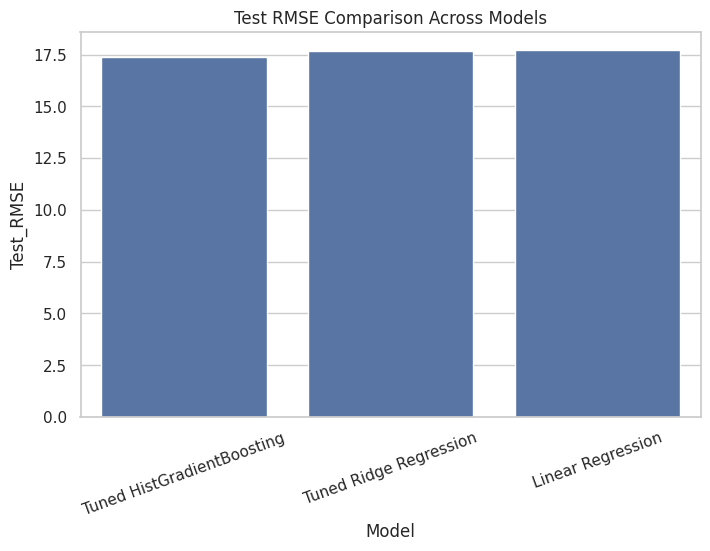

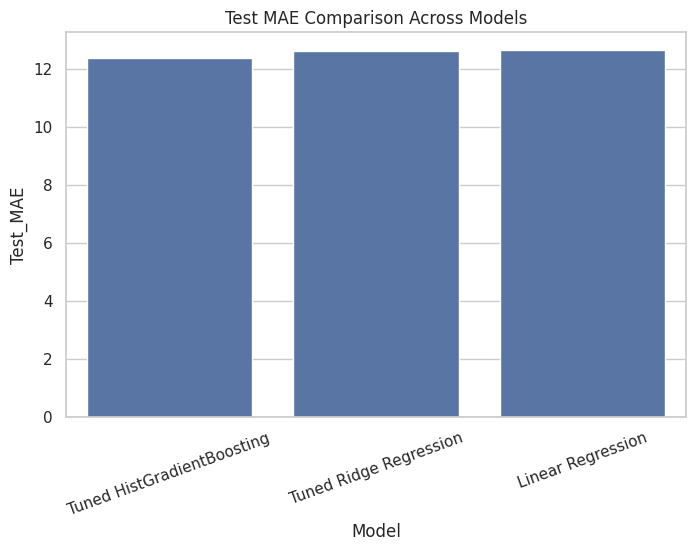

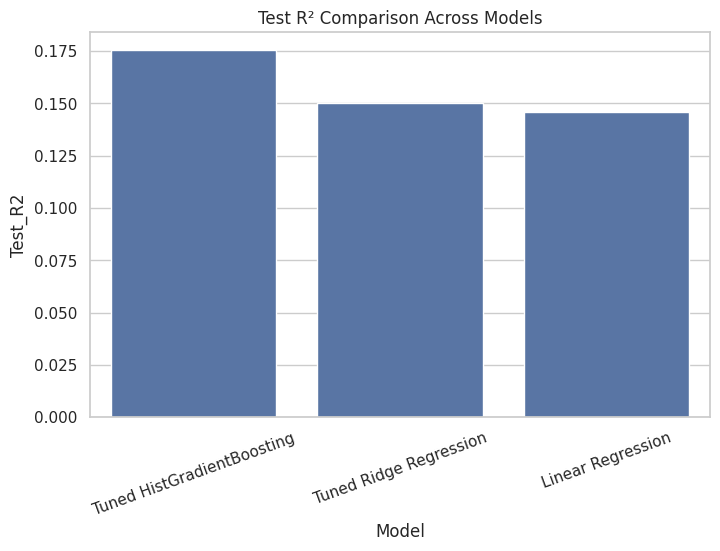

In [ ]:
print("\n========== 8. MODEL COMPARISON PLOTS ==========")

plt.figure(figsize=(8, 5))
sns.barplot(data=test_results_df, x='Model', y='Test_RMSE')
plt.title('Test RMSE Comparison Across Models')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=test_results_df, x='Model', y='Test_MAE')
plt.title('Test MAE Comparison Across Models')
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=test_results_df, x='Model', y='Test_R2')
plt.title('Test R² Comparison Across Models')
plt.xticks(rotation=20)
plt.show()


========== 9. ACTUAL VS PREDICTED FOR CHOSEN NON-LINEAR MODEL ==========


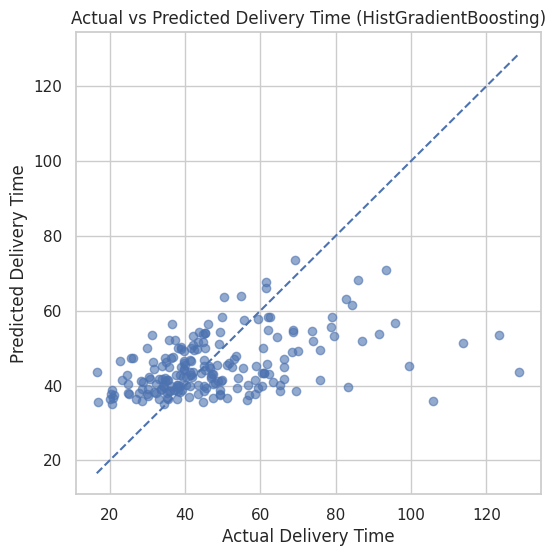

In [ ]:
print("\n========== 9. ACTUAL VS PREDICTED FOR CHOSEN NON-LINEAR MODEL ==========")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_hgb, alpha=0.6)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time (HistGradientBoosting)")

min_val = min(y_test.min(), y_test_pred_hgb.min())
max_val = max(y_test.max(), y_test_pred_hgb.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.show()

In [ ]:
print("\n========== 10. TRAIN VS TEST CHECK ==========")

best_hgb.fit(X_trainval, y_trainval)

y_trainval_pred_hgb = best_hgb.predict(X_trainval)

train_mae, train_rmse, train_r2 = evaluate_regression(y_trainval, y_trainval_pred_hgb)
test_mae, test_rmse, test_r2 = evaluate_regression(y_test, y_test_pred_hgb)

overfit_check_df = pd.DataFrame([
    {'Dataset': 'Train+Validation', 'MAE': train_mae, 'RMSE': train_rmse, 'R2': train_r2},
    {'Dataset': 'Test', 'MAE': test_mae, 'RMSE': test_rmse, 'R2': test_r2}
])

print("\n--- Train vs Test Performance ---")
print(overfit_check_df)


========== 10. TRAIN VS TEST CHECK ==========

--- Train vs Test Performance ---
            Dataset        MAE       RMSE        R2
0  Train+Validation   9.563146  13.139085  0.364423
1              Test  12.367627  17.395775  0.175369


In [ ]:
print("========== TASK C: CUSTOMER COMPLAINT PREDICTION ==========")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("\n========== 1. TARGET CONSTRUCTION AND FEATURE ENGINEERING ==========")

df_cls = df.copy()

# Binary target:
# 1 = complaint occurred
# 0 = no complaint recorded
df_cls['complaint_flag'] = (df_cls['complaint'] == 'YES').astype(int)

print("\n--- Complaint Class Distribution ---")
print(df_cls['complaint_flag'].value_counts())
print(df_cls['complaint_flag'].value_counts(normalize=True))

# Time features available at order creation
df_cls['created_at_dt'] = pd.to_datetime(df_cls['created_at'], format='%H:%M:%S')
df_cls['created_hour'] = df_cls['created_at_dt'].dt.hour
df_cls['created_minute'] = df_cls['created_at_dt'].dt.minute
df_cls['created_total_minutes'] = df_cls['created_hour'] * 60 + df_cls['created_minute']

# Cyclical encoding of time
minutes_in_day = 24 * 60
df_cls['created_time_sin'] = np.sin(2 * np.pi * df_cls['created_total_minutes'] / minutes_in_day)
df_cls['created_time_cos'] = np.cos(2 * np.pi * df_cls['created_total_minutes'] / minutes_in_day)

# Engineered order/load features
df_cls['price_per_item'] = df_cls['subtotal'] / df_cls['total_items'].replace(0, np.nan)
df_cls['item_price_range'] = df_cls['max_item_price'] - df_cls['min_item_price']
df_cls['available_partners'] = df_cls['total_onshift_partners'] - df_cls['total_busy_partners']
df_cls['busy_ratio'] = df_cls['total_busy_partners'] / df_cls['total_onshift_partners'].replace(0, np.nan)
df_cls['orders_per_busy_partner'] = df_cls['total_outstanding_orders'] / df_cls['total_busy_partners'].replace(0, np.nan)
df_cls['orders_per_onshift_partner'] = df_cls['total_outstanding_orders'] / df_cls['total_onshift_partners'].replace(0, np.nan)
df_cls['is_weekend'] = df_cls['created_day'].isin(['Saturday', 'Sunday']).astype(int)

print("\n--- Sample Engineered Features ---")
print(df_cls[[
    'created_at', 'created_total_minutes', 'created_time_sin', 'created_time_cos',
    'price_per_item', 'item_price_range', 'available_partners',
    'busy_ratio', 'orders_per_busy_partner', 'orders_per_onshift_partner',
    'is_weekend', 'complaint_flag'
]].head())

# Use only features available at order creation
features = [
    'market_id',
    'store_primary_category',
    'order_protocol',
    'total_items',
    'subtotal',
    'min_item_price',
    'max_item_price',
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders',
    'created_day',
    'created_holiday',
    'created_time_sin',
    'created_time_cos',
    'price_per_item',
    'item_price_range',
    'available_partners',
    'busy_ratio',
    'orders_per_busy_partner',
    'orders_per_onshift_partner',
    'is_weekend'
]

target = 'complaint_flag'

X = df_cls[features].copy()
y = df_cls[target].copy()

numeric_features = [
    'total_items',
    'subtotal',
    'min_item_price',
    'max_item_price',
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders',
    'created_time_sin',
    'created_time_cos',
    'price_per_item',
    'item_price_range',
    'available_partners',
    'busy_ratio',
    'orders_per_busy_partner',
    'orders_per_onshift_partner',
    'is_weekend'
]

categorical_features = [
    'market_id',
    'store_primary_category',
    'order_protocol',
    'created_day',
    'created_holiday'
]

# 60 / 20 / 20 split with stratification because target is imbalanced
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("\n--- Split Sizes ---")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

========== TASK C: CUSTOMER COMPLAINT PREDICTION ==========

========== 1. TARGET CONSTRUCTION AND FEATURE ENGINEERING ==========

--- Complaint Class Distribution ---
complaint_flag
0    756
1    244
Name: count, dtype: int64
complaint_flag
0    0.756
1    0.244
Name: proportion, dtype: float64

--- Sample Engineered Features ---
           created_at  created_total_minutes  created_time_sin  \
0 1900-01-01 05:04:03                    304          0.970296   
1 1900-01-01 02:27:48                    147          0.598325   
2 1900-01-01 04:15:41                    255          0.896873   
3 1900-01-01 03:43:41                    223          0.826590   
4 1900-01-01 04:14:36                    254          0.894934   

   created_time_cos  price_per_item  item_price_range  available_partners  \
0          0.241922      218.750000               175                 3.0   
1          0.801254     1069.000000              1700                -1.0   
2          0.442289      537.500000    

In [ ]:
print("\n========== 2. PREPROCESSING, BASELINES, AND TUNING ==========")

# Preprocessing pipeline (same as before)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

def evaluate_classification(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

# ONLY 3 MODELS TOTAL
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ])
}

print("\n--- Baseline Validation Results ---")
validation_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    scores = evaluate_classification(y_val, y_val_pred)
    scores['Model'] = name
    validation_results.append(scores)

validation_results_df = pd.DataFrame(validation_results).sort_values(
    by=['F1', 'Balanced_Accuracy'], ascending=False
)

print(validation_results_df)

# ONLY tune Random Forest (main model)
print("\n--- Random Forest Hyperparameter Tuning ---")

rf_pipeline = models['Random Forest']

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 8, 12],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)

best_rf = rf_grid.best_estimator_

# Validate tuned Random Forest
print("\n--- Tuned Random Forest Validation ---")

y_val_pred_rf = best_rf.predict(X_val)
rf_scores = evaluate_classification(y_val, y_val_pred_rf)

print(rf_scores)


========== 2. PREPROCESSING, BASELINES, AND TUNING ==========

--- Baseline Validation Results ---
   Accuracy  Balanced_Accuracy  Precision    Recall        F1  \
1     0.670           0.602244   0.365079  0.469388  0.410714   
0     0.625           0.579335   0.324324  0.489796  0.390244   
2     0.770           0.558184   0.636364  0.142857  0.233333   

                 Model  
1        Decision Tree  
0  Logistic Regression  
2        Random Forest  

--- Random Forest Hyperparameter Tuning ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}

--- Tuned Random Forest Validation ---
{'Accuracy': 0.76, 'Balanced_Accuracy': np.float64(0.5929179618867415), 'Precision': 0.52, 'Recall': 0.2653061224489796, 'F1': 0.35135135135135137}



========== 3. TEST EVALUATION ==========

--- Test Results ---
   Accuracy  Balanced_Accuracy  Precision    Recall        F1  \
0     0.675           0.646912   0.391892  0.591837  0.471545   
2     0.775           0.637316   0.562500  0.367347  0.444444   
1     0.630           0.499932   0.244898  0.244898  0.244898   

                 Model  
0  Logistic Regression  
2        Random Forest  
1        Decision Tree  

Best Model: Logistic Regression

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8413    0.7020    0.7653       151
           1     0.3919    0.5918    0.4715        49

    accuracy                         0.6750       200
   macro avg     0.6166    0.6469    0.6184       200
weighted avg     0.7312    0.6750    0.6934       200



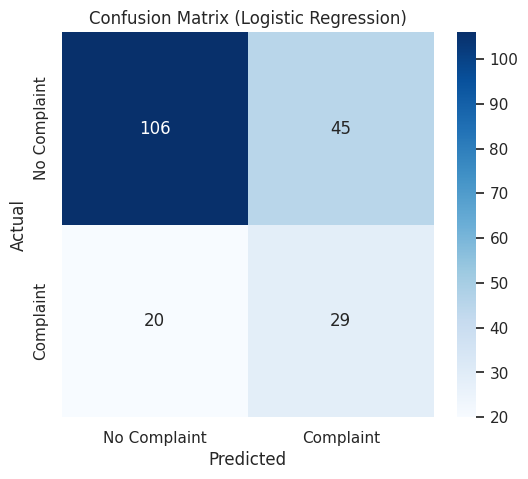

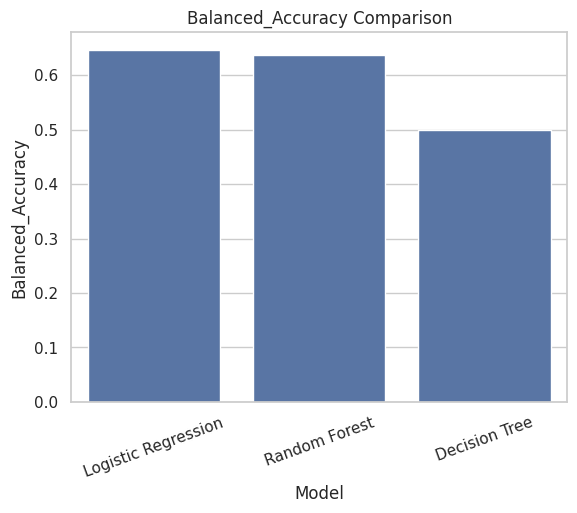

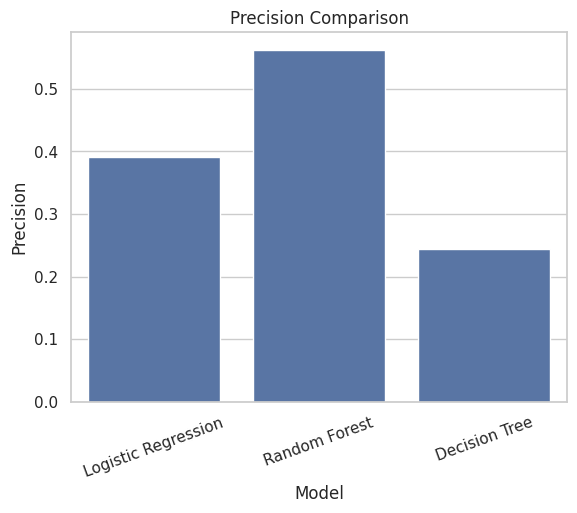

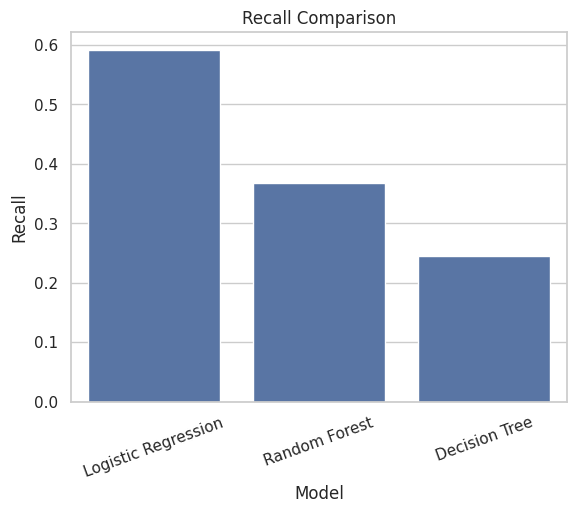

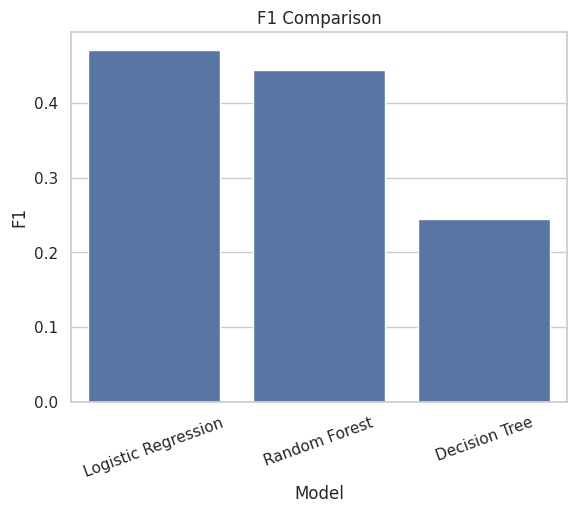

In [ ]:
print("\n========== 3. TEST EVALUATION ==========")

# Combine train + validation
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

test_results = []

# Logistic Regression
logreg = models['Logistic Regression']
logreg.fit(X_trainval, y_trainval)
y_pred_logreg = logreg.predict(X_test)
scores = evaluate_classification(y_test, y_pred_logreg)
scores['Model'] = 'Logistic Regression'
test_results.append(scores)

# Decision Tree
dt = models['Decision Tree']
dt.fit(X_trainval, y_trainval)
y_pred_dt = dt.predict(X_test)
scores = evaluate_classification(y_test, y_pred_dt)
scores['Model'] = 'Decision Tree'
test_results.append(scores)

# Tuned Random Forest (main model)
best_rf.fit(X_trainval, y_trainval)
y_pred_rf = best_rf.predict(X_test)
scores = evaluate_classification(y_test, y_pred_rf)
scores['Model'] = 'Random Forest'
test_results.append(scores)

test_results_df = pd.DataFrame(test_results).sort_values(
    by=['F1', 'Balanced_Accuracy'], ascending=False
)

print("\n--- Test Results ---")
print(test_results_df)

# Select best model
best_model_name = test_results_df.iloc[0]['Model']
print("\nBest Model:", best_model_name)

predictions = {
    'Logistic Regression': y_pred_logreg,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

y_best = predictions[best_model_name]

# Classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_best, digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Complaint', 'Complaint'],
            yticklabels=['No Complaint', 'Complaint'])
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Metric plots
for metric in ['Balanced_Accuracy', 'Precision', 'Recall', 'F1']:
    plt.figure()
    sns.barplot(data=test_results_df, x='Model', y=metric)
    plt.title(f'{metric} Comparison')
    plt.xticks(rotation=20)
    plt.show()

# Feature importance if RF is best
if best_model_name == 'Random Forest':
    print("\n--- Feature Importance ---")

    trained_preprocessor = best_rf.named_steps['preprocessor']
    trained_model = best_rf.named_steps['model']

    num_features = numeric_features
    cat_features = list(
        trained_preprocessor.named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )

    all_features = num_features + cat_features

    importance_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': trained_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print(importance_df.head(10))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
    plt.title('Top Feature Importances')
    plt.show()